<a href="https://colab.research.google.com/github/byamasu-patrick/graph-neural-network-lab/blob/main/gcn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Convolutional Networks (GCN): A From-Scratch PyTorch Implementation
By **Byamasu Patrick Paul**
> *I am a Machine Learning Researcher and an MSc Computer Science (by Research) candidate at the Malawi University of Science and Technology. Previously, I served as Chief Technology Officer at AlooChat (Kuwait).
My research focuses on autonomous agents, graph neural networks, reinforcement learning, multi-agent interactions and game theory, with an emphasis on sequential decision making under uncertainty. I am particularly interested in developing scalable learning algorithms that enable intelligent agents to communicate, coordinate, and make decisions effectively in complex and dynamic environments. The long-term goal of my research is to advance the development of intelligent autonomous agents capable of robust interaction and collaboration with other agents to solve challenging real-world problems.*

In the previous notebook, we built a simple Graph Neural Network (GNN) from scratch to understand the fundamental ideas behind learning on graph-structured data. Our implementation was based on the simple formulation

$$
\mathbf{H} = (\mathbf{A} + \mathbf{I})\mathbf{X}\mathbf{W},
$$

where $\mathbf{A}$ is the adjacency matrix describing the graph connectivity, $\mathbf{I}$ is the identity matrix that introduces self-loops so that every node also considers its own features, $\mathbf{X}$ is the node feature matrix, and $\mathbf{W}$ is a learnable weight matrix.

Although this simple model demonstrated how information propagates through a graph, it omitted several important components that make modern Graph Neural Networks stable, expressive, and effective. In particular, it did not normalize the graph structure, which can cause node representations to grow uncontrollably as information is repeatedly aggregated from neighboring nodes.

In this notebook, we implement the **Graph Convolutional Network (GCN)** introduced by **Thomas Kipf and Max Welling** in their landmark paper *Semi-Supervised Classification with Graph Convolutional Networks* (ICLR, 2017). GCN has become one of the most influential Graph Neural Network architectures, serving as the foundation for many subsequent models including Graph Attention Networks (GAT), GraphSAGE, Graph Isomorphism Networks (GIN), and numerous graph learning methods applied in recommendation systems, computer vision, computational biology, chemistry, knowledge graphs, and multi-agent reinforcement learning.

Before deriving the GCN equations, it is important to first understand the computational framework that underpins nearly all modern Graph Neural Networks.

## Message Passing Framework

Most Graph Neural Networks can be viewed through a common computational paradigm known as the **Message Passing Neural Network (MPNN)** framework. This framework was formalized by **Gilmer et al. (2017)** in the influential paper *Neural Message Passing for Quantum Chemistry*, which unified many graph learning methods under a single mathematical framework.

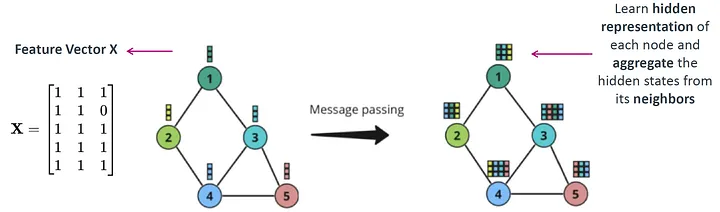

The central idea is simple. Every node learns its representation by repeatedly exchanging information, or **messages**, with its neighboring nodes. Instead of processing each node independently, a node aggregates information from its local neighborhood and combines it with its own representation. Repeating this process across multiple layers allows information to propagate through the graph, enabling each node to capture increasingly larger structural contexts.

The general message passing framework is defined as

$$
\mathbf{m}_v^{(l+1)}
=
\mathrm{AGGREGATE}^{(l)}
\left(
\left\{
\mathbf{h}_u^{(l)}
:
u \in \mathcal{N}(v)
\right\}
\right),
$$

followed by

$$
\mathbf{h}_v^{(l+1)}
=
\mathrm{UPDATE}^{(l)}
\left(
\mathbf{h}_v^{(l)},
\mathbf{m}_v^{(l+1)}
\right),
$$

or equivalently,

$$
\mathbf{h}_v^{(l+1)}
=
\mathrm{UPDATE}^{(l)}
\left(
\mathbf{h}_v^{(l)},
\mathrm{AGGREGATE}^{(l)}
\left(
\left\{
\mathbf{h}_u^{(l)}
:
u \in \mathcal{N}(v)
\right\}
\right)
\right).
$$

where

- $\mathbf{h}_v^{(l)}$ denotes the representation of node $v$ at layer $l$.
- $\mathcal{N}(v)$ denotes the set of neighboring nodes connected to node $v$.
- $\mathrm{AGGREGATE}(\cdot)$ combines information received from neighboring nodes.
- $\mathrm{UPDATE}(\cdot)$ computes the new node representation using the aggregated information together with the node's current representation.

Nearly all modern Graph Neural Networks follow this framework. The main differences between architectures lie in how the aggregation and update functions are designed.

## Understanding Message Passing

The message passing process can be understood in four intuitive steps.

### 1. Initialization

Every node begins with an initial feature vector from the node feature matrix $\mathbf{X}$. These features depend on the application.

Examples include:

- **Citation networks:** word frequencies or document embeddings.
- **Molecular graphs:** atom type, atomic number, charge, or chemical properties.
- **Social networks:** user profile attributes or behavioral information.
- **Recommendation systems:** user and item embeddings.
- **Multi-Agent Reinforcement Learning:** an agent's local observation, position, velocity, remaining energy, sensor readings, communication state, or any other information available locally to that agent.

These initial features form the starting point for representation learning.


### 2. Message Passing (Neighborhood Aggregation)

Each node collects information from its neighboring nodes.

This is achieved through an aggregation function such as

- Sum
- Mean
- Maximum

An important property of the aggregation function is that it must be **permutation invariant**. Since neighboring nodes have no inherent ordering, changing their order should not change the aggregated result.

For example, if node 1 is connected to nodes 2 and 3, it aggregates the feature vectors from those neighbors before updating its own representation.

### 3. Update Step

Once each node has gathered information from its neighbors, the next step is to transform these aggregated features into a new representation.

So our simple Graph Neural Network used the following learning rule

$$
\mathbf{h} = (\mathbf{A}+\mathbf{I})\mathbf{X}\mathbf{W},
$$

This simple formulation captures the essence of message passing, but it has an important limitation.

Suppose one node has only one neighbor while another has one thousand neighbors. After aggregation, the highly connected node will accumulate far more information than the sparsely connected one. As a result, nodes with many neighbors dominate the learning process, while nodes with only a few neighbors contribute much less.

This imbalance can make learning unstable, particularly for graphs whose node degrees vary significantly.

A natural solution is to normalize the aggregated information so that every node contributes more fairly, regardless of how many neighbors it has.

To achieve this, we introduce the degree matrix.

Let

$$
\tilde{\mathbf{A}}=\mathbf{A}+\mathbf{I}
$$

denote the adjacency matrix with self-loops, and let

$$
\tilde{\mathbf{D}}_{ii}
=
\sum_j \tilde{\mathbf{A}}_{ij}
$$

be the corresponding degree matrix, where each diagonal entry contains the number of neighbors of node $i$ (including itself).

Using this degree matrix, we obtain our first normalized graph learning rule

$$
\mathbf{H}
=
\sigma
\left(
\mathbf{W}
\tilde{\mathbf{D}}^{-1}
\tilde{\mathbf{A}}
\mathbf{X}
\right),
$$

where

- $\tilde{\mathbf{A}}$ is the adjacency matrix with self-loops.
- $\tilde{\mathbf{D}}^{-1}$ normalizes each node by its degree.
- $\mathbf{W}$ is the learnable weight matrix.
- $\sigma(\cdot)$ is a nonlinear activation function such as ReLU.

The nonlinear activation is important because, without it, stacking multiple graph layers would simply produce another linear transformation. Nonlinear activation functions allow the network to learn more expressive representations and capture complex relationships within the graph.

This normalization is a significant improvement over the original learning rule. Highly connected nodes no longer overwhelm the learning process, while nodes with only a few neighbors continue to contribute meaningful information.

**Takeaway**: Adding the degree normalization was one of the key insights in the development of the Graph Convolutional Network (GCN) a simple tweak that made GNNs much more robust and expressive.

## References

Gilmer, J., Schoenholz, S. S., Riley, P. F., Vinyals, O., & Dahl, G. E. (2017). *Neural Message Passing for Quantum Chemistry*. Proceedings of the 34th International Conference on Machine Learning (ICML).

Kipf, T. N., & Welling, M. (2017). *Semi-Supervised Classification with Graph Convolutional Networks*. International Conference on Learning Representations (ICLR).

In [10]:
# Let's install the same packages we used in our previous GNN from scratch implementation
!pip install networkx[default]

In [11]:
# For GPU (CUDA 12.x)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# OR for CPU-only version
# pip install torch torchvision torchaudio

Looking in indexes: https://download.pytorch.org/whl/cu121


In [12]:
# Install core PyG packages and its dependencies
!pip install torch-geometric

# (Optional) Install additional operators if needed
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.4.0+cu121.html


In [13]:
import torch
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj

# Let's build a basic adjacency matrix from the graph. So, assume we are using the Cora dataset
# (this dataset provides 'edge_index' - a list of graph edges)
from torch_geometric.datasets import Planetoid
cora_dataset = Planetoid(root="data/Cora", name="Cora")[0]

# Convert the edge list to a dense adjacency matrix A
A = to_dense_adj(cora_dataset.edge_index)[0]

# Let's add a self loop using torch.eye
I = torch.eye(len(A))
A = A + I

# Then, let's define the degree matrix
D = A.sum(dim=1)
D_inv = torch.diag((1.0) / (D + 1e-6))

In [14]:
import torch.nn as nn

class BasicGCN(nn.Module):
  """
    Implements the improved rule:
        normalized:  h = σ( W · D^{-1} A~ X )
    where:
        A~  -> adjacency matrix with self-loops
        D   -> degree matrix (used to compute D^{-1})
  """
  def __init__(self, in_features, hidden_features, out_features, activation=nn.ReLU):
        super().__init__()
        self.W = nn.Linear(in_features, hidden_features, bias=True)
        self.classifier = nn.Linear(hidden_features, out_features, bias=True)
        self.activation = activation()

  def forward(self, inputs):
        # Retrieve inputs from dictionary
        X = inputs["node_features"]            # (N, F_in)
        A_tilde = inputs["adjacency_norm"]     # (N, N)
        D_inv = inputs["inverse_degree_matrix"] # (N, N)

        # ----- Improved Learning rule -----
        # Message passing with left normalization: D^{-1} A~ X
        H = D_inv @ (A_tilde @ X)

        # Apply learnable weights
        H = self.W(H)
        H = self.activation(H)
        H = self.classifier(H)

        # Log-softmax for multiclass node classification
        return F.log_softmax(H, dim=1)

In [15]:
# Define model
in_features = cora_dataset.x.size(1)
hidden_features = 16
out_features = int(cora_dataset.y.max().item() + 1)

model = BasicGCN(in_features, hidden_features, out_features)

# Prepare inputs
inputs = {
    "node_features": cora_dataset.x,
    "adjacency_norm": A,
    "inverse_degree_matrix": D_inv,
}

# Forward pass
out = model(inputs)
print("Output shape:", out.shape)  # (N, num_classes)
print(out[:5])

Output shape: torch.Size([2708, 7])
tensor([[-1.9590, -1.8356, -1.8948, -1.8454, -2.0972, -1.9987, -2.0184],
        [-1.9687, -1.8361, -1.8857, -1.8496, -2.0768, -1.9926, -2.0385],
        [-1.9807, -1.8302, -1.9040, -1.8210, -2.0897, -1.9919, -2.0353],
        [-1.9492, -1.8541, -1.8619, -1.8800, -2.0964, -1.9913, -2.0126],
        [-1.9780, -1.8440, -1.8876, -1.8561, -2.0853, -1.9974, -1.9967]],
       grad_fn=<SliceBackward0>)


So far, we have improved our original graph learning rule by introducing **left normalization**, which scales the aggregated features by the inverse degree matrix,

$$
\tilde{\mathbf{D}}^{-1}\tilde{\mathbf{A}}.
$$

This ensures that nodes with many neighbors no longer dominate the aggregation process. However, the Graph Convolutional Network proposed by **Kipf and Welling (2017)** goes one step further by using **symmetric normalization**.

The resulting GCN layer is

$$
\mathbf{H}^{(l+1)}
=
\sigma
\left(
\tilde{\mathbf{D}}^{-\frac{1}{2}}
\tilde{\mathbf{A}}
\tilde{\mathbf{D}}^{-\frac{1}{2}}
\mathbf{H}^{(l)}
\mathbf{W}^{(l)}
\right),
$$

where

- $\mathbf{H}^{(l)}$ is the node feature matrix at layer $l$,
- $\mathbf{W}^{(l)}$ is the learnable weight matrix,
- $\tilde{\mathbf{A}}=\mathbf{A}+\mathbf{I}$ is the adjacency matrix with self-loops,
- $\tilde{\mathbf{D}}$ is the corresponding degree matrix, and
- $\sigma(\cdot)$ is a nonlinear activation function such as ReLU.

Notice that the degree matrix appears **on both sides** of the adjacency matrix. This means that both the node sending the message and the node receiving it are normalized equally, leading to a more balanced propagation of information throughout the graph.

### Why Symmetric Normalization?

The motivation comes from **spectral graph theory**.

Graph convolution can be derived as a filtering operation on a graph using the **normalized graph Laplacian**, defined as

$$
\mathbf{L}_{\text{norm}}
=
\mathbf{I}
-
\mathbf{D}^{-\frac{1}{2}}
\mathbf{A}
\mathbf{D}^{-\frac{1}{2}}.
$$

Unlike left normalization, the normalized Laplacian is **symmetric**, which gives it several desirable mathematical properties. In particular, the corresponding propagation operator

$$
\tilde{\mathbf{D}}^{-\frac{1}{2}}
\tilde{\mathbf{A}}
\tilde{\mathbf{D}}^{-\frac{1}{2}}
=
\left(
\tilde{\mathbf{D}}^{-\frac{1}{2}}
\tilde{\mathbf{A}}
\tilde{\mathbf{D}}^{-\frac{1}{2}}
\right)^T
$$

is also symmetric.

This symmetry means that information flows without introducing a directional bias. Messages exchanged between neighboring nodes are weighted consistently, making feature propagation more balanced and improving numerical stability during training.

### Intuition

The difference between the two normalization strategies is easy to understand.

**Left normalization**

$$
\tilde{\mathbf{D}}^{-1}\tilde{\mathbf{A}}
$$

only normalizes the **receiving node**. Each node averages the messages it receives from its neighbors, but the influence of the sender is not explicitly taken into account.

**Symmetric normalization**

$$
\tilde{\mathbf{D}}^{-\frac{1}{2}}
\tilde{\mathbf{A}}
\tilde{\mathbf{D}}^{-\frac{1}{2}}
$$

normalizes **both the sender and the receiver**. Every message is scaled according to the degrees of both connected nodes, preventing highly connected hub nodes from overwhelming the learning process while preserving balanced feature propagation across the graph.

This simple modification is one of the key reasons why the Graph Convolutional Network is both stable and effective.

## Implementing the Graph Convolutional Network

We now have all the ingredients needed to implement the original Graph Convolutional Network from scratch.

Rather than relying on high-level libraries, we will first build every component ourselves to understand exactly how graph convolution works. Once our implementation is complete, we will compare it with the optimized implementation provided by **PyTorch Geometric (PyG)** and see how the same ideas are translated into production-quality code.

> **Note: How PyTorch Geometric (PyG) Represents Graphs**
>
> Throughout this notebook, we have represented graphs using the adjacency matrix because it provides an intuitive way to understand graph convolution mathematically. However, most modern Graph Neural Network libraries, including **PyTorch Geometric (PyG)**, do **not** store graphs as dense adjacency matrices.
>
> Instead, PyG represents a graph using an **edge index**, a sparse representation of the graph connectivity.
>
> An `edge_index` is a tensor of shape
>
> $$
>  \text{Shape} = (2,\; E)
> $$
>
> where
>
> - The first row contains the **source nodes** (where each edge starts).
> - The second row contains the **target nodes** (where each edge ends).
>
> This representation is known as the **Coordinate (COO) format** and is much more memory-efficient than storing a large $N \times N$ adjacency matrix, especially for sparse graphs where most entries are zero.
>
> For example, instead of storing
>
> $$
> \mathbf{A} \in \mathbb{R}^{N \times N},
> $$
>
> PyG stores only the existing edges,
>
> $$
>  \mathbf{edge\_index} \in \mathbb{Z}^{2 \times E},
> $$
>
> where $E$ is the number of edges in the graph.
>
> PyG layers such as `GCNConv`, `GATConv`, and `GraphSAGE` operate directly on this sparse representation. Internally, they perform all the message passing, neighborhood aggregation, normalization, and feature transformations without ever constructing a dense adjacency matrix.
>
> Another major advantage of this representation is that it makes batching multiple graphs straightforward. When several graphs are combined into a mini-batch, PyG automatically:
>
> - Shifts node indices so that graphs do not overlap.
> - Concatenates their `edge_index` tensors into a single larger graph.
> - Maintains a `batch` vector that records which graph each node belongs to.
>
> This sparse representation is one of the main reasons PyTorch Geometric is able to train Graph Neural Networks efficiently on large real-world datasets.

In [33]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv

In [34]:
# Reproducibility & device
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [35]:
# 1. Load the Cora dataset
# Cora is a *single* graph: each node is a paper, edges are citations.
# PyG provides boolean masks: train_mask, val_mask, test_mask to split nodes for semi-supervised node classification.
root = os.path.join("data", "Cora")
dataset = Planetoid(root=root, name="Cora", transform=NormalizeFeatures())

# move the single graph to device
data = dataset[0].to(device)

num_features = dataset.num_node_features  # input dimension
num_classes = dataset.num_classes         # number of target classes

print(f"Nodes: {data.num_nodes}, Edges: {data.num_edges}")
print(f"Node feature dim: {num_features}, Classes: {num_classes}")
print(
    f"Splits — train: {int(data.train_mask.sum())}, "
    f"val: {int(data.val_mask.sum())}, test: {int(data.test_mask.sum())}"
)

Nodes: 2708, Edges: 10556
Node feature dim: 1433, Classes: 7
Splits — train: 140, val: 500, test: 1000


In [36]:
# 2. Define the GCN
class GCN(nn.Module):
    """
    A 2-layer Graph Convolutional Network using symmetric normalization
    internally (as implemented by PyG's GCNConv).
    H^{(l+1)} = ReLU( Â_norm H^{(l)} W^{(l)} ), with dropout between layers.
    """
    def __init__(self, in_features, hidden_features, out_features, dropout=0.5):
        super().__init__()
        # First graph conv: input -> hidden
        self.gcn1 = GCNConv(in_features, hidden_features, cached=True, normalize=True)
        # Second graph conv: hidden -> logits (one per class)
        self.gcn2 = GCNConv(hidden_features, out_features, cached=True, normalize=True)
        self.dropout = dropout

    def forward(self, x, edge_index):
        """
        x: (N, F) node features
        edge_index: (2, E) COO-format graph connectivity
        """
        # Layer 1: graph conv + nonlinearity + dropout
        x = self.gcn1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Layer 2: graph conv -> logits per class
        x = self.gcn2(x, edge_index)
        return x  # raw, unnormalized scores (logits)

In [37]:
model = GCN(num_features, hidden_features=16, out_features=num_classes, dropout=0.5).to(device)

# 3. Optimizer & loss
# CrossEntropyLoss expects raw logits; it applies log-softmax + Negative Log Likelyhood internally.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

In [38]:
# 4. Train / Eval helpers
# -------------------------
@torch.no_grad()
def accuracy(logits, y):
    """Compute classification accuracy."""
    preds = logits.argmax(dim=-1)
    return (preds == y).float().mean().item()

def train_one_epoch():
    model.train()
    optimizer.zero_grad()
    # Forward on all nodes, but compute loss only on training subset
    logits = model(data.x, data.edge_index)

    loss = criterion(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate():
    """Return (val_loss, val_acc, test_acc) to monitor training."""
    model.eval()
    logits = model(data.x, data.edge_index)

    # Validation metrics
    val_loss = criterion(logits[data.val_mask], data.y[data.val_mask]).item()
    val_acc  = accuracy(logits[data.val_mask], data.y[data.val_mask])

    # Test accuracy (report at the end; do not tune on this!)
    test_acc = accuracy(logits[data.test_mask], data.y[data.test_mask])

    return val_loss, val_acc, test_acc

In [39]:
# 5. Training loop
best_val_acc = 0.0
best_test_acc_at_best_val = 0.0
epochs = 300

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch()
    val_loss, val_acc, test_acc = evaluate()

    # Track the best validation performance and the corresponding test acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc_at_best_val = test_acc

    if epoch % 20 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc*100:5.2f}% | "
            f"test_acc: {test_acc*100:5.2f}%"
        )

print("\nDone!")
print(f"Best val acc: {best_val_acc*100:.2f}%")
print(f"Test acc at best val: {best_test_acc_at_best_val*100:.2f}%")

Epoch 001 | train_loss: 1.9459 | val_loss: 1.9441 | val_acc: 14.40% | test_acc: 15.70%
Epoch 020 | train_loss: 1.7174 | val_loss: 1.8137 | val_acc: 52.60% | test_acc: 53.60%
Epoch 040 | train_loss: 1.3281 | val_loss: 1.5922 | val_acc: 70.40% | test_acc: 70.30%
Epoch 060 | train_loss: 0.9540 | val_loss: 1.3363 | val_acc: 76.00% | test_acc: 77.20%
Epoch 080 | train_loss: 0.6925 | val_loss: 1.1445 | val_acc: 77.60% | test_acc: 79.00%
Epoch 100 | train_loss: 0.5591 | val_loss: 1.0391 | val_acc: 76.60% | test_acc: 79.50%
Epoch 120 | train_loss: 0.4700 | val_loss: 0.9573 | val_acc: 77.40% | test_acc: 80.20%
Epoch 140 | train_loss: 0.4071 | val_loss: 0.9211 | val_acc: 77.80% | test_acc: 80.10%
Epoch 160 | train_loss: 0.3849 | val_loss: 0.8713 | val_acc: 77.80% | test_acc: 80.10%
Epoch 180 | train_loss: 0.3435 | val_loss: 0.8448 | val_acc: 77.80% | test_acc: 80.20%
Epoch 200 | train_loss: 0.3223 | val_loss: 0.8328 | val_acc: 78.00% | test_acc: 79.90%
Epoch 220 | train_loss: 0.3000 | val_loss: 

# Next Steps

Congratulations! You have successfully implemented the original Graph Convolutional Network (GCN) from scratch. This implementation provides a solid foundation for understanding how graph convolution works before relying on high-level libraries such as PyTorch Geometric.

As you continue experimenting, consider exploring the following:

- **Increase the hidden dimension.** Try using 32, 64, or even 128 hidden features to learn richer node representations.
- **Tune the hyperparameters.** Experiment with different learning rates, weight decay values, dropout probabilities, and training epochs to improve model performance.
- **Explore deeper architectures.** Stack additional GCN layers and observe how performance changes. Keep an eye on over-smoothing as the network becomes deeper.
- **Experiment with different datasets.** Apply your implementation to other citation networks or graph datasets to see how well it generalizes.
- **Scale to larger graphs.** For real-world graphs containing millions of nodes, dense adjacency matrices become impractical. Modern GNN libraries address this using sampling techniques such as **GraphSAINT**, **ClusterGCN**, and **Neighbor Sampling**, which make training efficient on large-scale graphs.

In the next notebook, we will continue building our understanding of Graph Neural Networks by exploring another influential architecture and comparing its behavior with the Graph Convolutional Network.